**Group information**

| Family name | First name | Email address |
| ----------- | ---------- | ------------- |
| Fernández            | Pablo          | pablo.fernandeza@bse.eu              |

# Semantic segmentation - Homework

## 1. Instructions

This tutorial explores how to automatically extract building footprints from aerial images. The objective is to perform semantic segmentation, or approximate the function that maps input images to class probabilities for each pixel. For this assignment, we use the U-Net convolutional network architecture [(Ronneberger et al. 2015)](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28). The GPU implementation of PyTorch is recommended.

The image dataset consists of 3347 colour images, each with dimensions $3 \times 256 \times 256$, sourced from [Minh (2013)](http://www.cs.toronto.edu/~vmnih/data/). Each image corresponds to a 300-square-metre area within the state of Massachusetts. The labels are building footprint vectors derived from [OpenStreetMap](https://www.openstreetmap.org/relation/61315), which have been rasterised into binary masks matching the spatial extent and resolution of the input images. For efficient storage, images and labels are saved in the JPEG format.

![U-Net model](unet_diagram.jpg)

## 2. Utilities

### 2.1. Libraries and device setup

In [1]:
# Packages

# Utilities
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Deep learning
import torch
from torch import nn, utils
from torchmetrics import classification

# Custom library
from hw1_library import nn_model, utilities, visualizations

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)
print(f'Using device: {device}')

# Utilities
classes = {0:'non-building', 255:'building'}

Using device: cuda


### 2.2. Downloading the data

In [2]:
# download_data()

### 2.3. Set path to data folder

Adjust to the location of the data downloaded above (consider that it is a large folder).

In [4]:
data_path = '/home/pablo/Documents/BSE-DSDM/3-Applications_of_DL/data_hw1/'

## 3. Questions

### 1)

1. Load the images and labels as `torch.Tensor` of dimensions $n \times d \times h \times w$. Normalise the images and labels between 0 and 1 and set the data type as `torch.float32`.

<small>Note: In the label images, pixel values of 0 indicate non-building areas, while 255 indicate buildings. Due to JPEG's lossy compression, some values may slightly differ from 0 or 255. You can round the pixel values to restore binary labels.</small>

First, we define a function that takes in the path of an image, reads it as a numpy array, offers the possibility of normalizing the images between 0 and 1 and then reads it as a torch file. Furthermore, for `label` files, they are rounded to either 0 or 255 (the closest value). For more information, see the function `read_image_numpy` in the `hw1_library`, 

Second, we read all of the images and labels as `torch.float32` files, and load them as a `torch.tensor` separately.

In [5]:
# Load data

# List all of the names of the images in the image folder (without the prefix)
files = [file.replace('image_', '') for file in os.listdir(os.path.join(data_path, 'images'))]

# Read images and labels and stack them into a single tensor
images = torch.stack([utilities.read_image_numpy(file = os.path.join(data_path, "images", f"image_{file}"), dtype=torch.float32, normalize=True) for file in files])
labels = torch.stack([utilities.read_image_numpy(file = os.path.join(data_path, "labels", f"label_{file}"), dtype = torch.float32, normalize=True) for file in files])

# Delete the files path list
del files

### 2)

2. Check the array dimensions and display several image–label pairs to ensure that they are correctly aligned.

#### Array dimensions

Checking the array dimensions.

In [6]:
print('Size of the image tensor:', images.size())
print('Size of the label tensor:', labels.size())

# Check if the number of images and labels are equal
if images.size(0) != labels.size(0):
    raise ValueError('Number of images and labels do not match!')

Size of the image tensor: torch.Size([3347, 3, 256, 256])
Size of the label tensor: torch.Size([3347, 1, 256, 256])


i.e., we have:
- $n$: 3,347 images and their corresponding labels.
- $d$: 3 color dimensions for the images, 1 for the labels (grayscale).
- $h$: both are 256 height (which is expected as they should match).
- $w$: both are 256 width (which is expected as they should match).

#### Display of image-label sample pairs

Displaying several image-label pairs (visual inspection to check alignment).

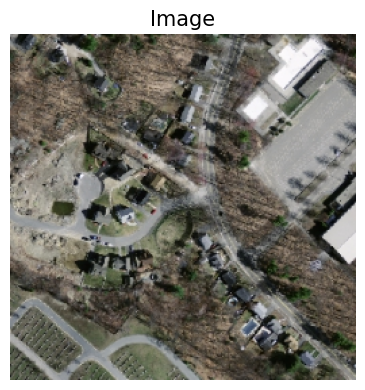

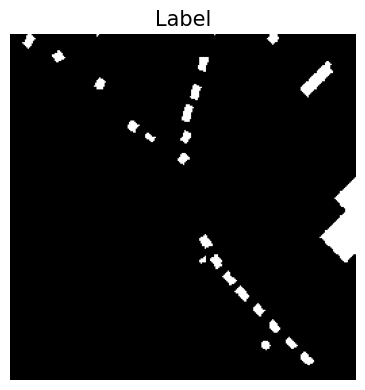

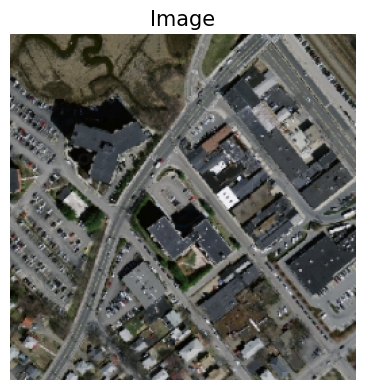

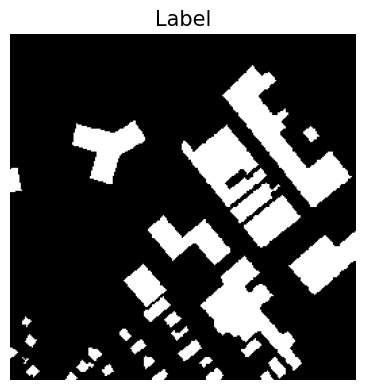

In [6]:
# Displays random images, labels and images
for i in torch.randint(0, len(images), (2,)):
  visualizations.display_image(image = images[i], title = 'Image')
  visualizations.display_image(image = labels[i], title = 'Label')

### 3)

3. Format the data as a `TensorDataset` and partition the observations into training (75%) and test (25%) samples. For each sample, create a `DataLoader` with a batch size suitable for your hardware (e.g. between 32 and 256).

<small>Note: Optionally, you can also include a validation sample by splitting the dataset into 70% training, 15% validation, and 15% test.</small>

Useful documentation: [`torch.utils.data`](https://pytorch.org/docs/stable/data.html)

In [7]:
# Format the data as a TensorDataset
dataset = utils.data.TensorDataset(images, labels)  # Create a TensorDataset from the image and label tensors
print(len(dataset))

3347


In [8]:
# Split the dataset into training, validation and test sets
train_dataset, val_dataset, test_dataset = utils.data.random_split(dataset, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(42))

# Set batch size
batch_size = 64

# Set number of physical CPU cores (as int) to use for data loading
num_workers = os.cpu_count() // 2 if os.cpu_count() is not None else 0

# Create DataLoaders for each dataset
train_loader = utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,  # Shuffle the training data to prevent learning order bias, overfitting and improve generalization
    num_workers=num_workers,  # Use multiple workers for faster data loading
    pin_memory=True if device == 'cuda' else False,  # Pin memory for faster data transfer to GPU
)

val_loader = utils.data.DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,  # Keep validation data in the same order for consistent evaluation
    num_workers=num_workers,  # Use multiple workers for faster data loading
    pin_memory=True if device == 'cuda' else False,  # Pin memory for faster data transfer to GPU
)

test_loader = utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,  # Keep test data in the same order for consistent evaluation
    num_workers=num_workers,  # Use multiple workers for faster data loading
    pin_memory=True if device == 'cuda' else False,  # Pin memory for faster data transfer to GPU
)

### 4)

4. Using PyTorch, define a simplified U-Net model with the number of filters indicated in the figure above (i.e. 8, 16, 32, 64, 128, ...). Choose the appropriate activation functions for the hidden layers and the output layer.

<small>Note: Optionally, you can include batch normalisation and spatial dropout layers to improve the model’s optimisation and generalisation, respectively.</small>

![U-Net model](unet_diagram.jpg)

The basic structure of this network is the following:

1. **Input**: a tensor of shape $(N, 3, H, W)$.
2. **Encode** down through five levels, doubling channels each time and halving spatial dimensions.
3. **Bottleneck**: deepest features at 128 channels.
4. **Decode** back up, halving channels and doubling spatial dimensions, while concatenating corresponding encoder features to preserve fine details.
5. **Output**: apply a 1×1 convolution → Sigmoid to produce a mask of shape $(N, 1, H, W)$ with values in (0,1).

All of the classes below initialize the parameters at each layer with `__init__` and then implement a `forward` method that defines the forward pass of the neural network, which "takes the input data and passes it through the layers of the network to produce the output. This method is executed whenever the model is called to make a prediction or to compute the loss during training" ([reference](https://discuss.pytorch.org/t/what-is-the-difference-init-and-forward-in-a-network-model/173907?utm_source=chatgpt.com)).

#### The double convolution

The two convolutional layers are included everywhere in the network, from the encoding to the decoding. For more information, check `DoubleConv` in the library `hw1_library`.

Useful sources:
- [`Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d) - convolutional layer
- [`BatchNorm2d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d) - normalization layer
- [`ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU) - non-linear activation function

#### The encoder module (`Down`)

The class below represents one encoding step. For more information, check `Down` in the library `hw1_library`.

Useful sources:
- [`MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d) - pooling layer

#### The decoder module (`Up`)

This class represents one decoding step. It performs upsampling and concatenation with skip connection. For more information, check `Up` in the library `hw1_library`.

This class:

1. Upsamples via either bilinear interpolation or a learnable transposed convolution. See [`nn.Upsample`](https://pytorch.org/docs/stable/generated/torch.nn.Upsample.html#torch.nn.Upsample)
2. Pads if the resulting feature-map is off by 1 pixel in height/width. See [`nn.functional.pad`](https://pytorch.org/docs/stable/generated/torch.nn.functional.pad.html#torch.nn.functional.pad)
3. Concatenates with the corresponding encoder feature-map along the channel dimension (the “skip connection”). See [`torch.cat`](https://pytorch.org/docs/stable/generated/torch.cat.html)
4. Uses `DoubleConv` to fuse and refine these combined features.

#### Final 1 $\times$ 1 convolution

This convolution reduces the channels from whatever the last decoder output is (in the diagram, 8) down to the desired number of classes (1 for binary mask, as in this case - 0 for no building and 1 for building). For more information, check `OutConv` in the library `hw1_library`.

#### Putting all together in `UNet`

This class uses the constructions made above, and replicates the structure of the neural network in the diagram. For more information, check `UNet` in the library `hw1_library`.

Note that the output layer returns the logits, not probabilities, for compatibility with the loss function.

### 5)

5. Initialise the model and print its architecture. Select an appropriate optimisation algorithm and loss function.

<small>Note: To address class imbalance — since building pixels represent only a small fraction of the total — you can weight the loss function or use loss functions specifically designed for imbalance, such as [`torchvision.ops.sigmoid_focal_loss`](https://pytorch.org/vision/main/generated/torchvision.ops.sigmoid_focal_loss.html).</small>

#### Initializing the model

In [9]:
# Set the parameters for the U-Net model
n_channels = 3  # Number of input channels (RGB image)
n_classes = 1  # Number of output channels (1 for binary segmentation - building vs non-building)
base_filters = 8  # Number of filters in the first layer (check diagram)
dropout_p = 0.1  # Dropout probability for regularization
bilinear = False  # Use bilinear interpolation for upsampling (True) or transposed convolution (False)

# Initialize the model
model = nn_model.UNet(
    n_channels=n_channels,
    n_classes=n_classes, 
    base_filters=base_filters,
    dropout_p=dropout_p,
    bilinear=bilinear
)
model = model.to(device)  # Move the model to the specified device (GPU or CPU)
print(model)

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Dropout2d(p=0.1, inplace=False)
    )
  )
  (down1): Down(
    (pool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1),

#### Loss function (addressing class imbalance)

In [10]:
# Note that the images are already normalized to [0, 1] range

# Count pixels once, globally
n_pos = labels.sum()  # total “1” pixels
n_neg = labels.numel() - n_pos  # total “0” pixels
pos_weight = n_neg / (n_pos + 1e-6)  # avoid division by zero, inverse ratio of positive to negative pixels

# Print the number of positive and negative pixels
print(f'Number of positive pixels: {n_pos.item()}')
print(f'Number of negative pixels: {n_neg.item()}')
print(f'Ratio of positive to negative pixels: {n_pos.item() / n_neg.item()}')
print(f'Pos weight: {pos_weight.item()}')

# Create the loss function (BCEWithLogitsLoss for binary classification with logits)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

Number of positive pixels: 25226376.0
Number of negative pixels: 194122624.0
Ratio of positive to negative pixels: 0.12995072640270924
Pos weight: 7.695224285125732


We can see that non-building pixels are much more prevalent (only 13% of the total pixels in the labels correspond to buildings).

Through this weighting (see this [post](https://discuss.pytorch.org/t/pos-weight-and-weight-parameters-in-bcewithlogitsloss/130651?utm_source=chatgpt.com):

- If `pos_weight > 1`, positives get up-weighted.
- If `pos_weight < 1`, positives get down-weighted.

More information about the [`BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) class.

#### Optimization algorithm

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

References: [`torch.optim`](https://pytorch.org/docs/stable/optim.html)

### 6)

6. Write the PyTorch training routine and estimate the model parameters using the training sample.

<small>Note: If you use a validation sample, implement a validation routine and apply early stopping to prevent overfitting.<small>

#### Train-validation routine

[Basic guide](https://machinelearningmastery.com/creating-a-training-loop-for-pytorch-models/?utm_source=chatgpt.com) for creating a training loop.

This training routine includes (for more information, check out `train_model` in `hw1_library`):

1. Progress tracking with tqdm progress bars for both training and validation steps
2. Loss and IoU calculation for both training and validation sets. The IoU (Intersection over Union) metric is appropriate for segmentation tasks as it measures the overlap between the predicted segmentation and the ground truth.
3. Early stopping that monitors validation loss and stops training when no improvement is seen for a certain number of epochs
4. Best model saving that saves the model parameters (from the initialization in 5), weights with the lowest validation loss
5. Visualization of metrics to monitor the training process and check for overfitting

#### Estimating the model weights

In [12]:
# Set training parameters
num_epochs = 50      # Maximum number of epochs to train
patience = 10        # Number of epochs with no improvement after which training will be stopped
delta = 0.0001       # Minimum change in validation loss to qualify as improvement

# Train the model
model, history, best_val_loss = nn_model.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    patience=patience,
    delta=delta
)

Epoch 1/50
--------------------------------------------------


Val Loss: 1.1832: 100%|██████████| 8/8 [00:00<00:00, 10.48it/s]

Training Loss: 1.1960, IoU: 0.1192
Validation Loss: 1.2130, IoU: 0.0499
Validation loss improved from inf to 1.2130

Epoch 2/50
--------------------------------------------------



Val Loss: 1.0745: 100%|██████████| 8/8 [00:00<00:00, 10.45it/s]

Training Loss: 1.1281, IoU: 0.1304
Validation Loss: 1.0731, IoU: 0.2881
Validation loss improved from 1.2130 to 1.0731

Epoch 3/50
--------------------------------------------------


...

Training Loss: 0.7307, IoU: 0.4539
Validation Loss: 0.7142, IoU: 0.5338
Validation loss improved from 0.7169 to 0.7142

Epoch 49/50
--------------------------------------------------



Val Loss: 0.7098: 100%|██████████| 8/8 [00:00<00:00,  8.20it/s]

Training Loss: 0.7311, IoU: 0.4536
Validation Loss: 0.7131, IoU: 0.5234
Validation loss improved from 0.7142 to 0.7131

Epoch 50/50
--------------------------------------------------



Val Loss: 0.7080: 100%|██████████| 8/8 [00:00<00:00,  8.26it/s]

Training Loss: 0.7269, IoU: 0.4542
Validation Loss: 0.7071, IoU: 0.5289
Validation loss improved from 0.7131 to 0.7071

Loaded best model weights with validation loss: 0.7071


#### Saving the weights and the architecture after training

We define a function fitted to the previous code to load the model with the parameters that have been specified and the optimal weights.

In [13]:
# Example usage after training
utilities.save_model(model, 
           'unet_segmentation_try4', 
           best_val_loss,
           # Model architecture parameters defined in section 5
           n_channels=n_channels, 
           n_classes=n_classes, 
           base_filters=base_filters,
           dropout_p=dropout_p,
           bilinear=bilinear)

Model saved to models/unet_segmentation_try4_val_loss_0.7071.pth


#### Visualization of metrics

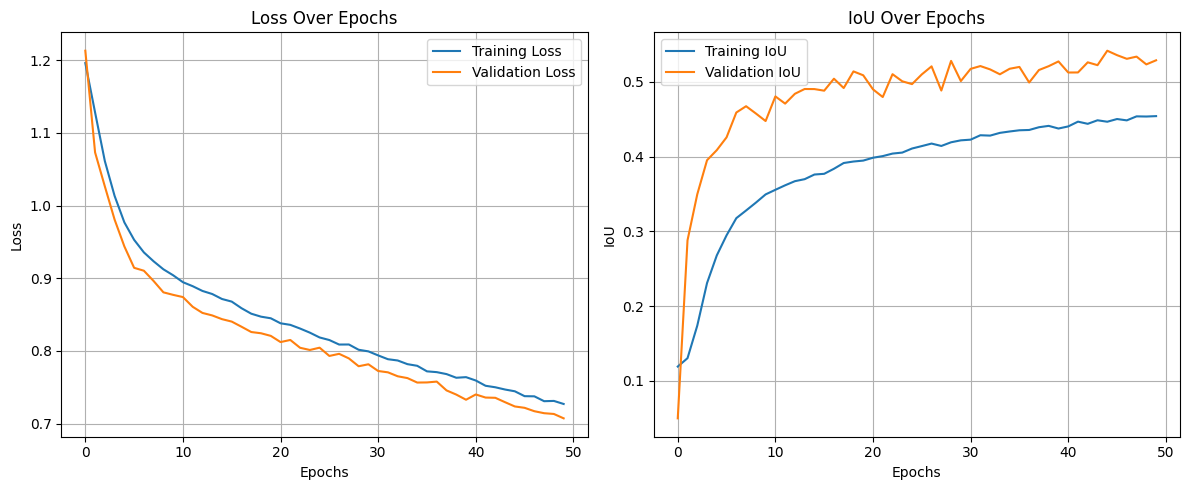

In [14]:
# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Convert GPU tensors to CPU for plotting (to avoid errors)
train_loss = [x.cpu().item() if torch.is_tensor(x) else x for x in history['train_loss']]
val_loss = [x.cpu().item() if torch.is_tensor(x) else x for x in history['val_loss']]
train_metrics = [x.cpu().item() if torch.is_tensor(x) else x for x in history['train_metrics']]
val_metrics = [x.cpu().item() if torch.is_tensor(x) else x for x in history['val_metrics']]

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot IoU
plt.subplot(1, 2, 2)
plt.plot(train_metrics, label='Training IoU')
plt.plot(val_metrics, label='Validation IoU')
plt.title('IoU Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Note that increasing the number of epochs further than 50 won't make a significant difference in this case - neither the loss nor the IoU will apparently decrease and increase significantly, respectively.

### 7)

7. Compute the predicted probabilities for the test images.

#### Loading a saved PyTorch model

To load a save model, we need to:
1. Initialize a new model with the same architecture
2. Load the state dictionary from the saved file (in the section "Estimating the model weights", this is done in the line `torch.save(model.state_dict(), [...])`)
3. Apply the state dictionary to the model

For more information, check `load_model` in `hw1_library`.

In [9]:
# Example usage
model = utilities.load_model('models/unet_segmentation_try3_val_loss_0.5782.pth')

Loaded model from models/unet_segmentation_try3_val_loss_0.5782.pth with parameters: {'n_channels': 3, 'n_classes': 1, 'base_filters': 8, 'dropout_p': 0.1, 'bilinear': False}
Best validation loss: 0.5782


#### Predicting probabilities for test images

For more information, check `predict` in `hw1_library`.

In [10]:
# Make predictions on the test set
test_predictions, test_labels = nn_model.predict(
    model=model,
    dataloader=test_loader,
    device=device,
    return_probs=False,  # Get probabilities instead of binary predictions
    threshold=0.5  # Only used if return_probs=False
)

print(f"Predictions shape: {test_predictions.shape}")
print(f"Labels shape: {test_labels.shape}")

Generating predictions: 100%|██████████| 8/8 [00:01<00:00,  5.99it/s]

Predictions shape: torch.Size([502, 256, 256])
Labels shape: torch.Size([502, 256, 256])


#### Visualizing sample images and their predictions

For more information, check `visualize_predictions` in `hw1_library`.

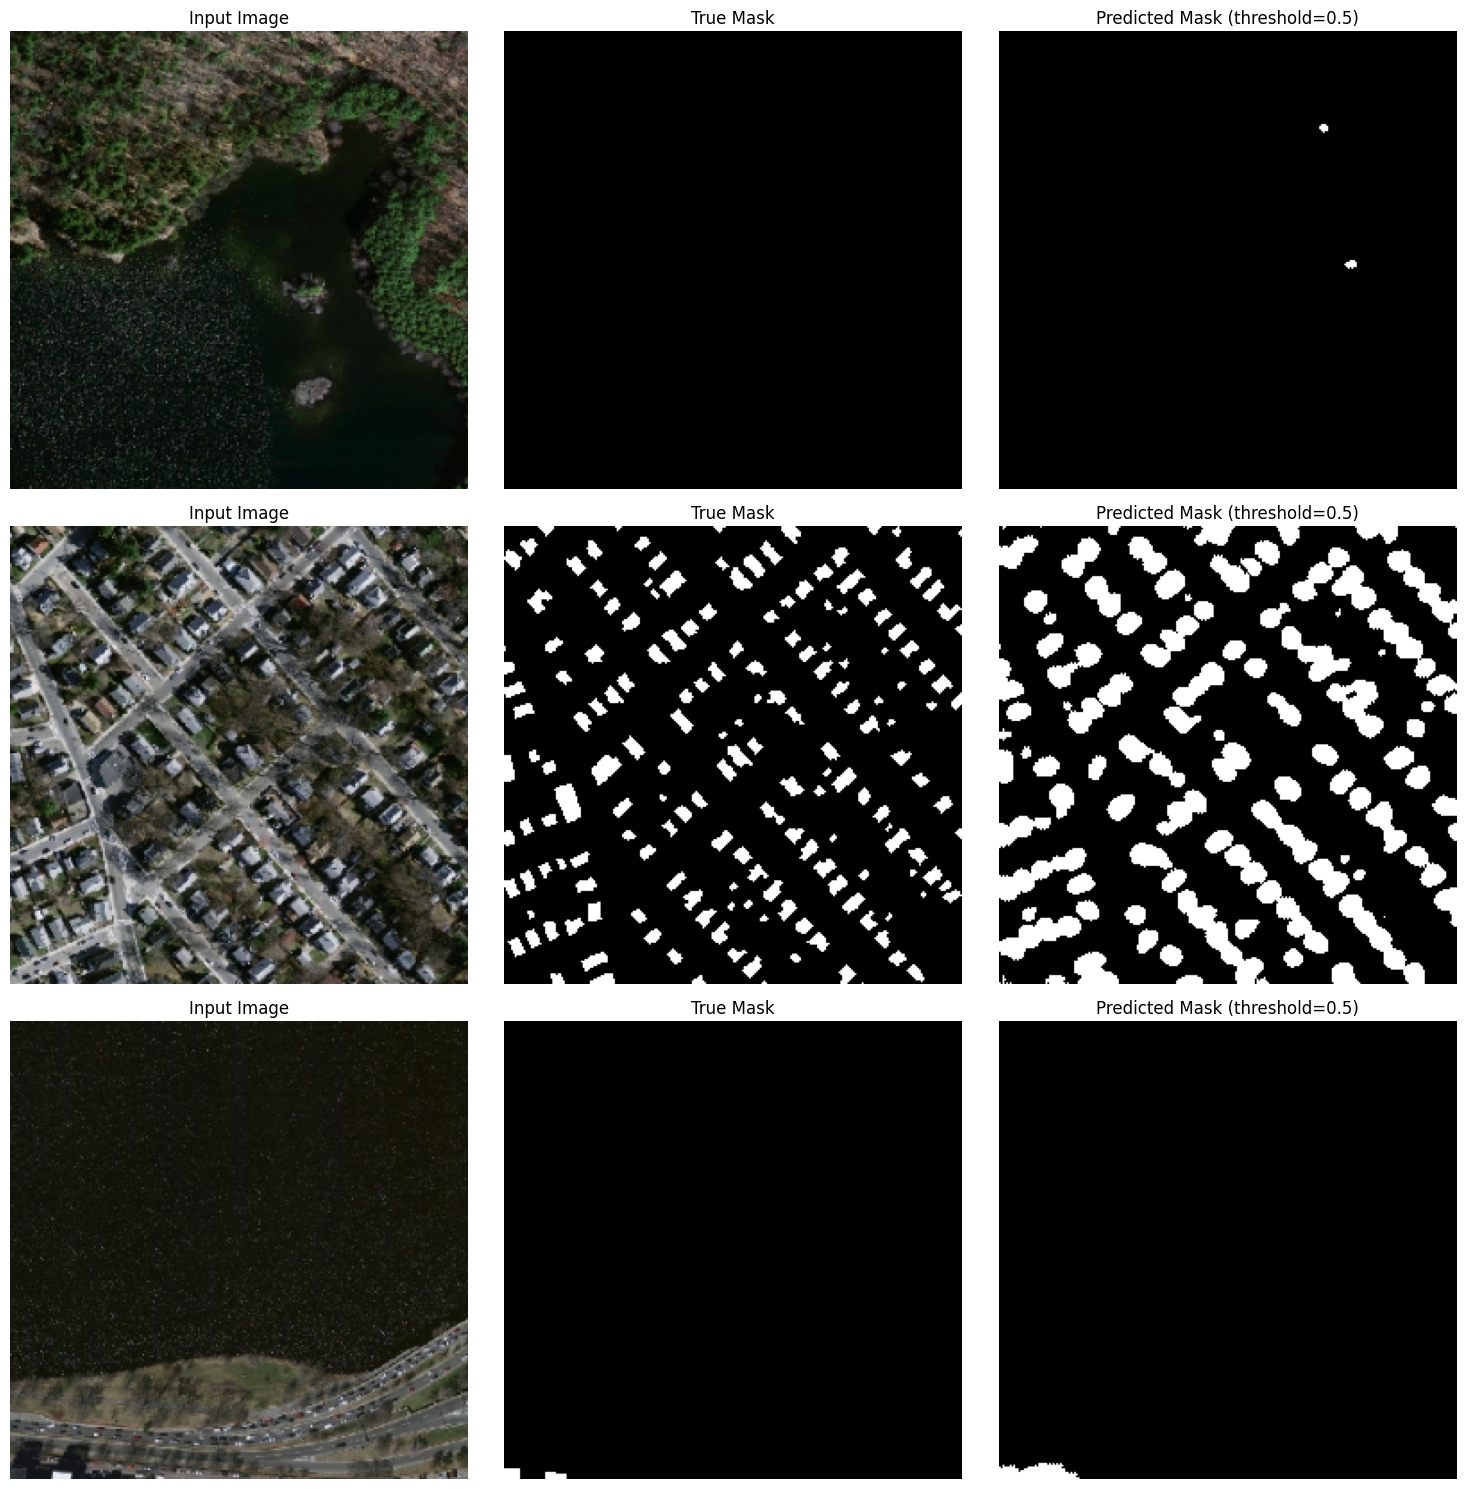

In [11]:
# Get a batch of test images and their labels
test_images_sample = []
test_true_masks_sample = []

# Extract a few batches from the test loader
for images, labels in test_loader:
    test_images_sample.append(images)
    test_true_masks_sample.append(labels.squeeze(1))
    if len(test_images_sample) >= 3:  # Get 3 batches at most
        break

# Concatenate batches
test_images_sample = torch.cat(test_images_sample, dim=0)
test_true_masks_sample = torch.cat(test_true_masks_sample, dim=0)

# Make predictions (just for 3 batches)
with torch.no_grad():
    model.eval()
    test_pred_logits = model(test_images_sample.to(device)).squeeze(1).cpu()  # Apply sigmoid to convert logits to probabilities (comment if using sigmoid in the output activation function)
    test_pred_probs_sample = torch.sigmoid(test_pred_logits).cpu()
    # test_pred_probs_sample = model(test_images.to(device)).squeeze(1).cpu()  # Uncomment if using sigmoid in the output activation function

# Visualize
visualizations.visualize_predictions(test_images_sample, test_true_masks_sample, test_pred_probs_sample, num_samples=3)

### 8)

8. Assess the model's generalisation performance by computing the confusion matrix, along with precision and recall metrics on the test sample. Comment on the results.

#### Confusion matrix

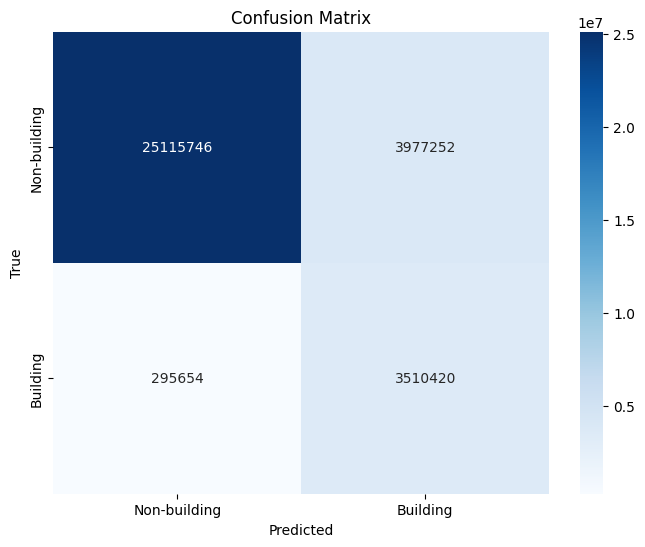

In [12]:
# Flatten the predictions and labels to 1D arrays for confusion matrix calculation
y_pred_flat = test_predictions.flatten()
y_true_flat = test_labels.flatten()

# Convert to numpy arrays if they're not already
if torch.is_tensor(y_pred_flat):
    y_pred_flat = y_pred_flat.cpu().numpy()
    y_true_flat = y_true_flat.cpu().numpy()

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_flat, y_pred_flat)

# Extract values from confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()

# Visualization of confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-building', 'Building'],
            yticklabels=['Non-building', 'Building'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

From left to right and up to down:
- The first cell represents the **true negatives** (the objects that were not buildings and that were correctly predicted),
- The second cell represents the  **false positives** (the objects that were not buildings but that were predicted as buildings),
- The third cell represents the **false negatives** (actual buildings that were not predicted as such), and
- The fourth cell represents the **true positives** (buildings that were predicted as such).

#### Precision, recall and F1-score

Manual predictions using the outputs of the confusion matrix as inputs.

In [13]:
# Calculate precision and recall manually
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nManually calculated metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Manually calculated metrics:
Precision: 0.4688
Recall: 0.9223
F1 Score: 0.6217


Robustness check with the `torchmetrics` library for computing the metrics.

In [14]:
# Initialize metrics
jaccard_metric = classification.BinaryJaccardIndex().to(device)
precision_metric = classification.BinaryPrecision().to(device)
recall_metric = classification.BinaryRecall().to(device)
f1_metric = classification.BinaryF1Score().to(device)

# Move tensors to the same device as the metrics to avoid errors
test_predictions_device = test_predictions.to(device)
test_labels_device = test_labels.to(device)

# Calculate metrics (make sure inputs are tensors)
iou_torch = jaccard_metric(test_predictions_device, test_labels_device)
precision_torch = precision_metric(test_predictions_device, test_labels_device)
recall_torch = recall_metric(test_predictions_device, test_labels_device)
f1_torch = f1_metric(test_predictions_device, test_labels_device)

print("\nTorchmetrics results:")
print(f"IoU: {iou_torch:.4f}")
print(f"Precision: {precision_torch:.4f}")
print(f"Recall: {recall_torch:.4f}")
print(f"F1 Score: {f1_torch:.4f}")


Torchmetrics results:
IoU: 0.4510
Precision: 0.4688
Recall: 0.9223
F1 Score: 0.6217


#### Full classification report

In [15]:
# Get detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_true_flat, y_pred_flat, 
                           target_names=['Non-building', 'Building']))


Classification Report:

              precision    recall  f1-score   support

Non-building       0.99      0.86      0.92  29092998
    Building       0.47      0.92      0.62   3806074

    accuracy                           0.87  32899072
   macro avg       0.73      0.89      0.77  32899072
weighted avg       0.93      0.87      0.89  32899072



#### Insights

- With the metrics computed above for a classification threshold of 0.5, we can observe that the recall is significantly higher than the precision. Since the recall represents the ratio of true positive predictions over all positive instances, this means that with a relatively low threshold of 0.5 we are mostly getting all of the positive instances (building predictions) right. In other words, wherever there are buildings, we are actually predicting that there is a building.
- Precision, on the other hand, tells a very different story: as the ratio of true positive predictions over all positive predictions, the model is showing signs of overpredicting building instances. In other words, the number of false positives is relatively high, which brings down the precision metric.
- These insights are also aligned with the full classification report: if we focus on the "building" class, we can observe the same comments that have been made about the trade-off that the model is making with a threshold of 0.5, which performs relatively well if we want to predict mostly all of the building pixels but quite badly for avoiding predicting buildings where there aren't.

### 9)

9. Implement a function to visualise true positives, true negatives, false positives, and false negatives as overlays on the input image.

For more information, check `visualize_segmentation_errors` and `visualize_segmentation_errors_sample` (for visualizing segmentation errors of just a sample) in `hw1_library`.


Sample 140:


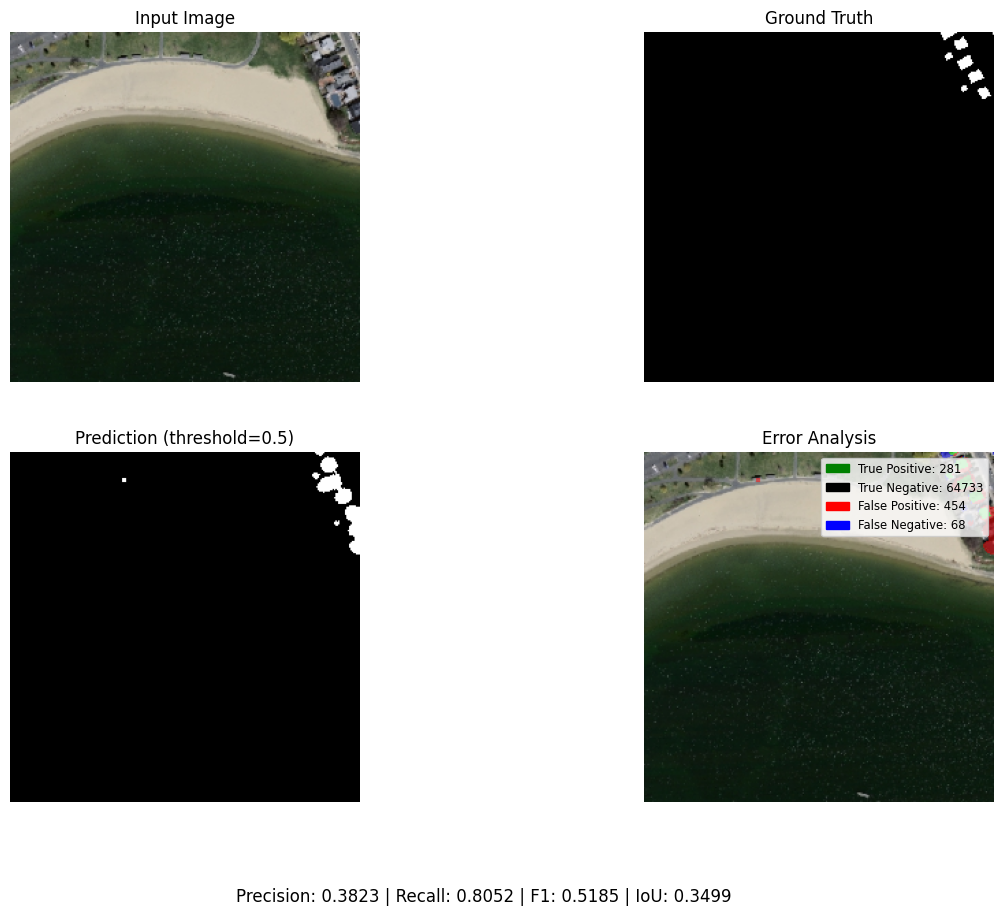


Sample 102:


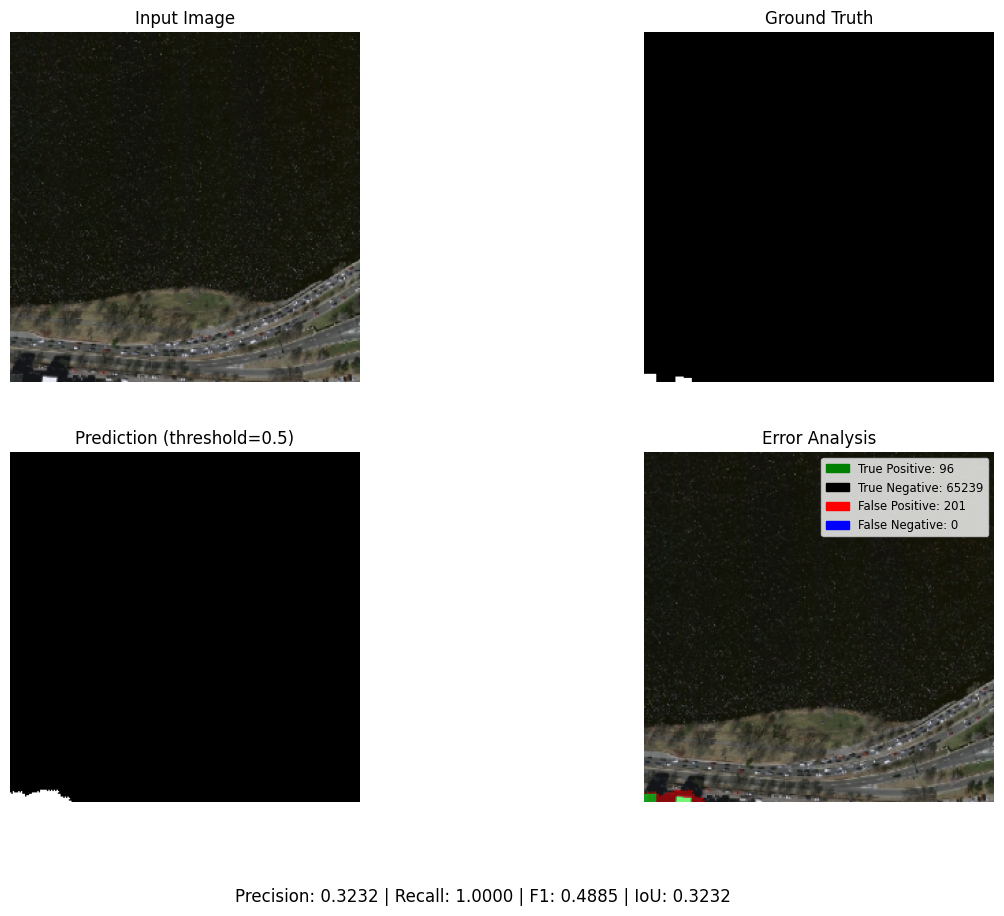


Sample 115:


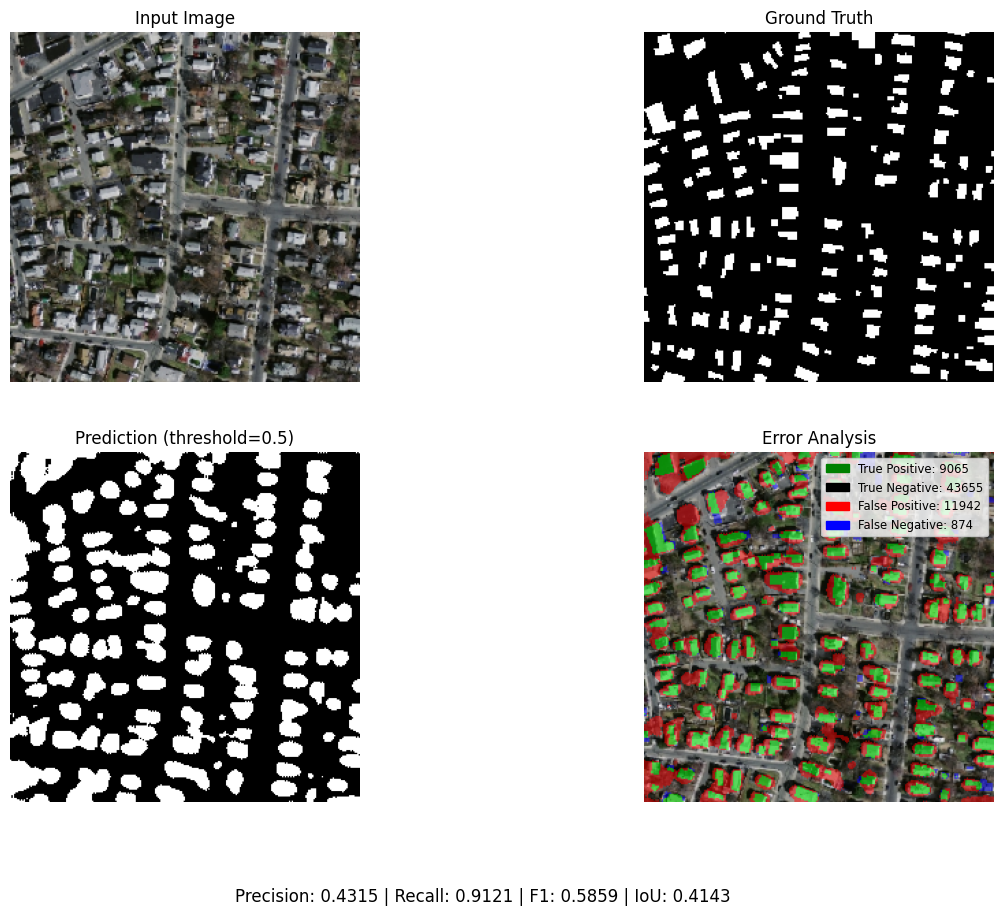


Average metrics across samples:
Precision: 0.3790
Recall: 0.9057
F1: 0.5310
Iou: 0.3625


In [16]:
# Visualize a few random samples
visualizations.visualize_segmentation_errors_sample(
    test_images_sample,
    test_true_masks_sample,
    test_pred_probs_sample,
    num_samples=3,
    threshold=0.5
)

### 10)

10. Assuming that we give equal importance to reducing false positives and false negatives, use a decision probability threshold that strikes the best balance between these two quantities.

Since we want to give equal importance to reduce false positives (related to precision, as it is the ratio of positive instances correctly predicted over all positive predictions) and false negatives (related to recall, since it is the ratio of positive instances correctly predicted over all positive instances), **we should probably aim for a decision probability threshold which maximizes the F1-score, since it is the harmonic mean of precision and recall**, where:

$$F1-score = \frac{2\times Precision \times Recall}{Precision + Recall}$$

To do that, it can be useful to start by plotting the precision-recall curve for different probability thresholds (just to visualize the trade-off when changing the probability threshold), and then search for the probability threshold which maximizes the F1-score.

#### Precision-recall curve with F1-score for different probability thresholds

In [17]:
# First, we load the model
model = utilities.load_model('models/unet_segmentation_try3_val_loss_0.5782.pth')

# Second, we make the predictions on the test set with the probabilities
test_predictions_prob, test_labels = nn_model.predict(
        model=model,
        dataloader=test_loader,
        device=device,
        return_probs=True  # Get probabilities instead of binary predictions
    )

Loaded model from models/unet_segmentation_try3_val_loss_0.5782.pth with parameters: {'n_channels': 3, 'n_classes': 1, 'base_filters': 8, 'dropout_p': 0.1, 'bilinear': False}
Best validation loss: 0.5782


Generating predictions: 100%|██████████| 8/8 [00:01<00:00,  6.43it/s]


In [18]:
# Third, we initialize the metrics and lists for storing the results
precision_metric = classification.BinaryPrecision().to(device)
recall_metric = classification.BinaryRecall().to(device)
f1_metric = classification.BinaryF1Score().to(device)

results = {
    'thresholds': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

# Fourth, we calculate the metrics for different thresholds 
for threshold in np.arange(0, 1.01, 0.005):

    # Move tensors to the same device as the metrics to avoid errors
    test_predictions_device = test_predictions_prob.to(device)
    test_labels_device = test_labels.to(device)

    # Convert probabilities to binary predictions using the threshold
    test_predictions_binary = (test_predictions_device > threshold).float()

    # Calculate metrics (make sure inputs are tensors)
    precision_torch = precision_metric(test_predictions_binary, test_labels_device)
    recall_torch = recall_metric(test_predictions_binary, test_labels_device)
    f1_torch = f1_metric(test_predictions_binary, test_labels_device)

    # Store the results
    results['thresholds'].append(threshold)
    results['precision'].append(precision_torch.item())
    results['recall'].append(recall_torch.item())
    results['f1_score'].append(f1_torch.item())

In [19]:
# Now, we convert the results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

results_df.head()

,thresholds,precision,recall,f1_score
0,0.000,0.115689,1.0,0.207386
1,0.005,0.115689,1.0,0.207386
2,0.010,0.115689,1.0,0.207386
3,0.015,0.115689,1.0,0.207386
4,0.020,0.115689,1.0,0.207386


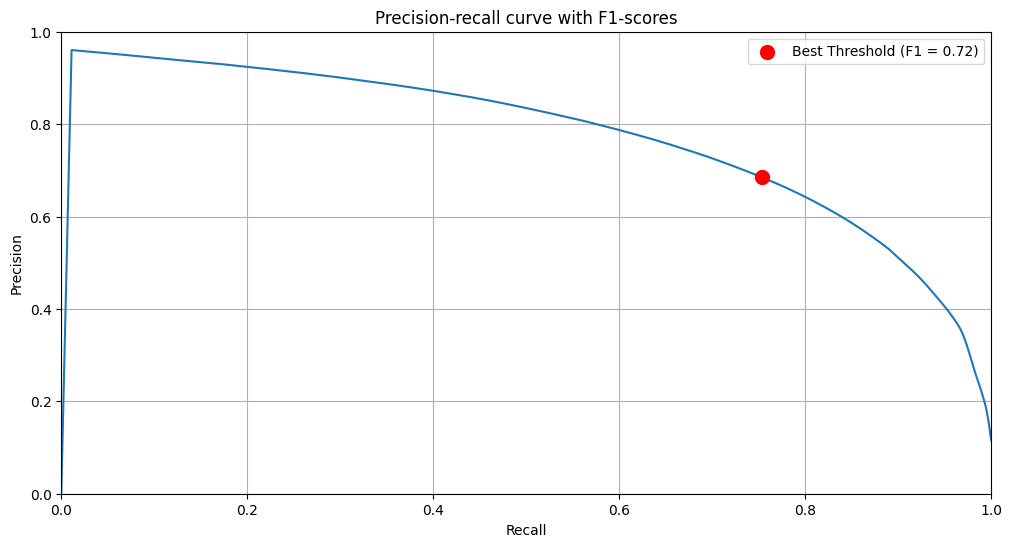

In [20]:
# Plot the 

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['recall'], results_df['precision'])
plt.title('Precision-recall curve with F1-scores')

# Add vertical and horizontal lines for precision and recall of maximum F1-score
max_f1_index = results_df['f1_score'].idxmax()
plt.scatter(results_df['recall'][max_f1_index], results_df['precision'][max_f1_index], 
            color='red', s=100, zorder=5, label=f'Best Threshold (F1 = {results_df['f1_score'][max_f1_index]:.2f})')

# Adjust scale of the axes
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add grid, labels and legend
plt.grid()
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.show()

- The beginning of the curve represents the highest probability thresholds possible, where (except for extremely high probability thresholds, where there seems to be few correct true positives) the precision is very high (as the number of false positives is very low).
- On the other hand, the end of the curve represents the lowest probability thresholds possible, where the recall converges to a high value (as the number of false negatives will be very low, as we will more easily classify an instance as positive).
- The precision converges, at the end of the curve, to the class imbalance proportion (of 13%, as shown in section 5), where we will classify all instances as positive. This happens because all the actual positives will be correctly predicted, but all the actual negatives will be incorrectly predicted.

In [21]:
# Print the best threshold in terms of the F1-score
print('Best threshold and metrics for the maximum F1-score:')
display(results_df.loc[results_df['f1_score'].idxmax()])

Best threshold and metrics for the maximum F1-score:


thresholds    0.730000
precision     0.684933
recall        0.753368
f1_score      0.717523
Name: 146, dtype: float64

#### Discussion

- In this case, the threshold that maximizes the F1-score to 71.8% is of 73% (i.e., if the predicted probability of having a building in a pixel is equal or above 73%, we will classify that pixel as "building", otherwise as "non-building").
- As shown in the precision-recall curve, this F1-score strikes a good balance between both metrics, which stay close to 70%.
- This balance is convenient in case that the decision-maker cares equally about avoiding false positives (precision) as false negatives (recall).